# Malaria Classification Project Overview

## Introduction

This project focuses on the development of a deep learning model for the classification of malaria cell images. Malaria, a life-threatening disease caused by Plasmodium parasites, is a major global health concern. In 202 alone, there were approximately `247 million` cases of malaria worldwide, leading to around ` 619 000 deaths`, with the majority occurring in sub-Saharan Africa. - [WHO](https://www.who.int/news-room/questions-and-answers/item/malaria?gclid=CjwKCAiAu9yqBhBmEiwAHTx5pyt9CdR0zouYdVCrYMq35x1vuxXRecc_bQx9fybnL3kjY6laCBXtQBoC0_QQAvD_BwE)

## Objective

The goal of this project is to create a model capable of distinguishing between two key classes:

- **Uninfected Cells:** Healthy red blood cells without malaria infection.
- **Parasitized Cells:** Red blood cells infected with Plasmodium parasites.

## Dataset

The dataset comprises a collection of images depicting both uninfected and parasitized cells. Sourced from the official NIH Malaria Datasets, it contains a total of `27,558` images.

## Methodology

We will leverage deep learning techniques, specifically Convolutional Neural Networks (CNNs), to train a model that can automatically learn and differentiate between features associated with infected and uninfected cells. The model will be trained on a labeled dataset and evaluated on a separate test set to assess its classification performance.

## Significance

Automated malaria cell classification has the potential to expedite the diagnostic process, especially in regions with limited access to healthcare resources. The successful implementation of this model could contribute to more efficient and accurate malaria diagnosis, aiding healthcare professionals in providing timely and targeted interventions.

Let's embark on this journey to develop a robust deep learning model for malaria cell classification!

## Acknowledgements
- [Malaria Cell Images Dataset](https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria/data)
- [NIH Malaria Datasets](https://ceb.nlm.nih.gov/repositories/malaria-datasets/)

# Import important libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import PIL
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img, array_to_img
from tensorflow.keras.applications.vgg19 import VGG19
import seaborn as sns

KeyboardInterrupt: 

In [29]:
import pathlib
path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"
data_dir = pathlib.Path(path).with_suffix('')

In [30]:
image_count = len(list(data_dir.glob('*/*.png')))
print(image_count)

27558


In [31]:
uninfected = list(data_dir.glob("Uninfected/*"))
parasitized = list(data_dir.glob("Parasitized/*"))
print("Number of uninfected cells", len(uninfected))
print("Number of uninfected cells", len(parasitized))

Number of uninfected cells 13780
Number of uninfected cells 13780


# Displaying some examples

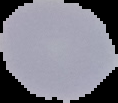

In [32]:
PIL.Image.open(uninfected[1])

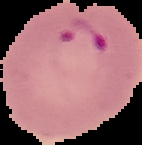

In [33]:
PIL.Image.open(parasitized[1])

In [34]:
batch_size = 32
img_height = 150
img_width = 150

In [35]:
image_gen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split = 0.3,
    rescale = 1/255
)

In [36]:
training_data = image_gen.flow_from_directory(
    data_dir,
    subset = "training",
    class_mode="binary",
    target_size = (img_width, img_height),
    batch_size = batch_size
)

validation_data = image_gen.flow_from_directory(
    data_dir,
    subset = "validation",
    class_mode="binary",
    target_size = (img_width, img_height),
    batch_size = batch_size
)

Found 19292 images belonging to 2 classes.
Found 8266 images belonging to 2 classes.


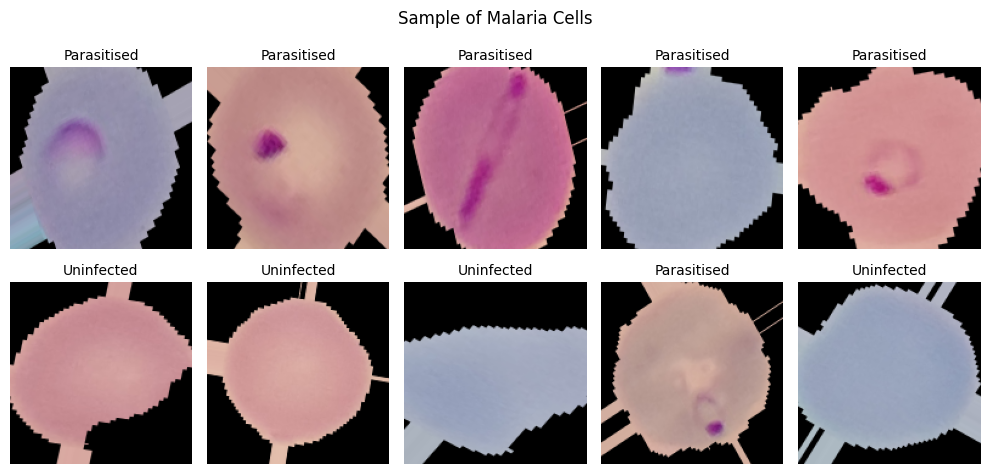

In [37]:
X_train, y_train = next(training_data)

fig = plt.figure(figsize=(10, 5))

for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.imshow(X_train[i])
    ax.axis("off")
    ax.set_title("Uninfected" if y_train[i] == 1 else "Parasitised", fontsize=10)
fig.suptitle("Sample of Malaria Cells")
plt.tight_layout()

# Building 'Home-Made' Network

## Our model Architecture

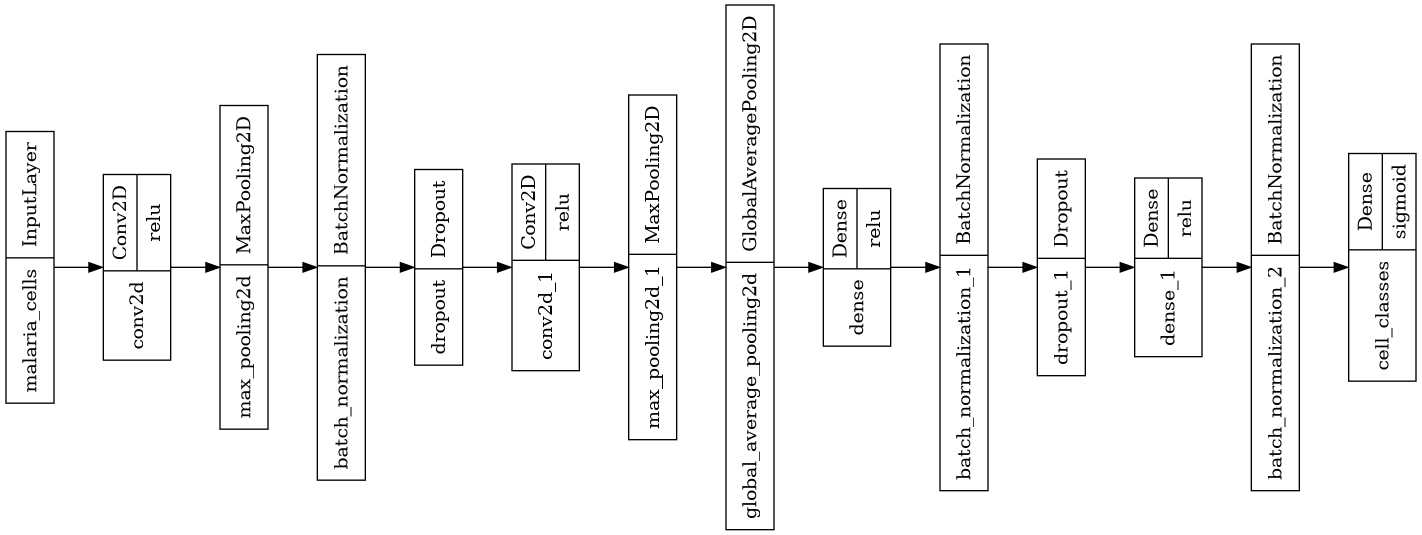

In [38]:
input = Input(shape = (img_width, img_height, 3), dtype=tf.float32, name="malaria_cells")
X = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding="same", activation="relu")(input)
X = MaxPooling2D(pool_size = (2, 2))(X)
X = BatchNormalization()(X)
X = Dropout(0.3)(X)
X = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding="same", activation="relu")(X)
X = MaxPooling2D(pool_size = (2, 2))(X)

X = GlobalAveragePooling2D()(X)
X = Dense(512, activation="relu")(X)
X = BatchNormalization()(X)
X = Dropout(0.3)(X)
X = Dense(256, activation="relu")(X)
X = BatchNormalization()(X)
output = Dense(1, activation="sigmoid", name="cell_classes")(X)

model = Model(inputs=input, outputs=output)

In [39]:
plot_model(model, "model.png", show_layer_activations=True)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 malaria_cells (InputLayer)  [(None, 150, 150, 3)]     0         
                                                                 
 conv2d_2 (Conv2D)           (None, 150, 150, 64)      1792      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 75, 75, 64)        0         
 g2D)                                                            
                                                                 
 batch_normalization_3 (Bat  (None, 75, 75, 64)        256       
 chNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 75, 75, 64)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 75, 75, 64)        3692

In [41]:
optim = tf.keras.optimizers.Adam()
loss = tf.keras.losses.BinaryCrossentropy()

model.compile(optimizer=optim, loss=loss, metrics=["accuracy"])

## Training our model

In [42]:
epochs = 5

checkpoint_filepath = '/tmp/checkpoint'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

early_stopping = tf.keras.callbacks.EarlyStopping(patience=3, min_delta=1e-3, restore_best_weights=True)

history = model.fit(training_data, epochs=epochs, validation_data=validation_data, callbacks=[model_checkpoint_callback, early_stopping])

Epoch 1/5


2023-11-18 20:06:14.200106: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/dropout_2/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 [==============================] - 177s 289ms/step - loss: 0.4840 - accuracy: 0.7728 - val_loss: 0.4768 - val_accuracy: 0.8010
Epoch 2/5
603/603 [==============================] - 173s 286ms/step - loss: 0.2277 - accuracy: 0.9281 - val_loss: 0.2181 - val_accuracy: 0.9359
Epoch 3/5
603/603 [==============================] - 173s 287ms/step - loss: 0.2020 - accuracy: 0.9376 - val_loss: 0.2089 - val_accuracy: 0.9398
Epoch 4/5
603/603 [==============================] - 172s 285ms/step - loss: 0.1880 - accuracy: 0.9428 - val_loss: 0.2039 - val_accuracy: 0.9375
Epoch 5/5
603/603 [==============================] - 179s 297ms/step - loss: 0.1808 - accuracy: 0.9443 - val_loss: 0.2711 - val_accuracy: 0.9528


In [43]:
model.save("malaria-cnn-v1.keras")

In [44]:
model.evaluate(validation_data)

259/259 [==============================] - 82s 315ms/step - loss: 0.2764 - accuracy: 0.9512


[0.2763952910900116, 0.9512460827827454]

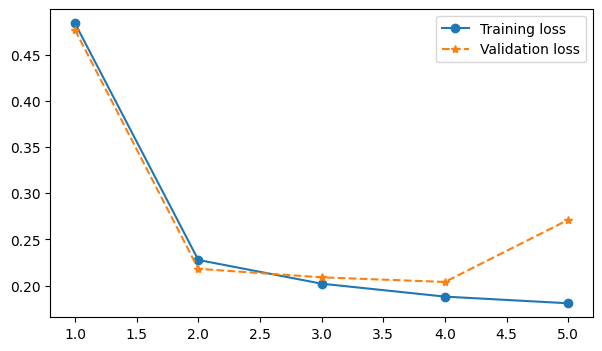

In [45]:
plt.figure(figsize=(7, 4))
ax = plt.axes()
ax.plot(range(1, epochs+1), history.history["loss"], marker="o", label="Training loss")
ax.plot(range(1, epochs+1), history.history["val_loss"], marker="*", ls="--", label="Validation loss")
ax.legend()
plt.show()

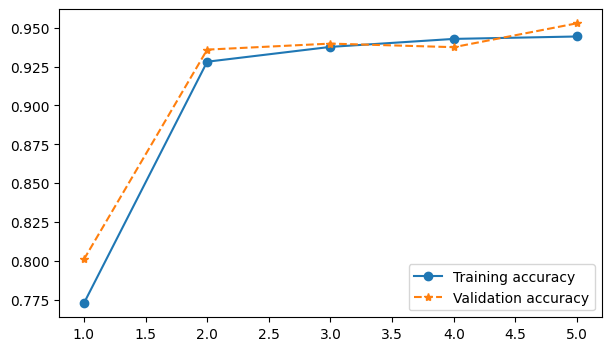

In [46]:
plt.figure(figsize=(7, 4))
ax = plt.axes()
ax.plot(range(1, epochs+1), history.history["accuracy"], marker="o", label="Training accuracy")
ax.plot(range(1, epochs+1), history.history["val_accuracy"], marker="*", ls="--", label="Validation accuracy")
ax.legend()
plt.show()

In [47]:
y_pred_proba = model.predict(validation_data).flatten()
y_pred_classes = (y_pred_proba >= 0.5).astype(np.int32)

259/259 [==============================] - 81s 312ms/step


In [49]:
def evaluate_ramdom_image(path, ax):
    image = load_img(str(path), target_size=(img_width, img_height))
    img_arr = img_to_array(image)
    img_arr /= 255
    pred = model.predict(img_arr.reshape(1, *img_arr.shape), verbose=0).flatten()
    label = "Parasitised" if pred < 0.5 else "Uninfected"
    ax.imshow(img_arr, vmin=1, vmax=1)
    ax.set_title(f"{label} - {pred[0]:.2%}", size=10)
    ax.axis("off")
    # plt.show()

In [50]:
parasitized_path = list(data_dir.glob("Parasitized/*"))
uninfected_path = list(data_dir.glob("Uninfected/*"))

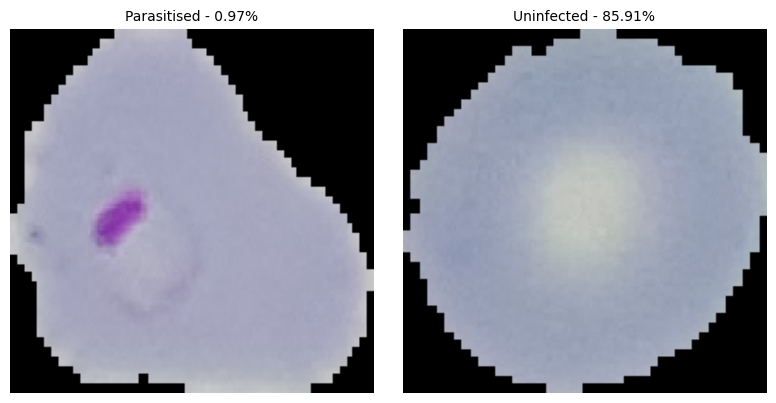

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
index = np.random.randint(len(parasitized_path))
evaluate_ramdom_image(parasitized_path[index], ax1)
evaluate_ramdom_image(uninfected_path[index], ax2)
plt.tight_layout()

---
# Using Transfer Learning -- VGG19

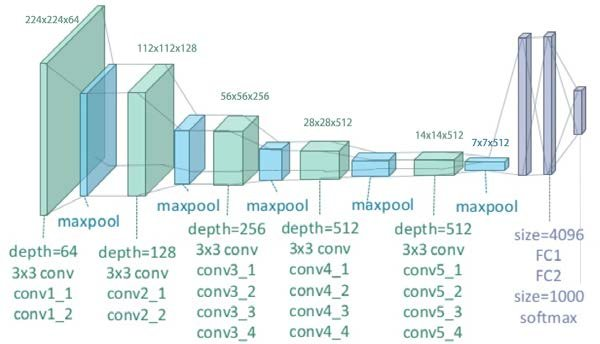

Source: [researchgate](https://www.researchgate.net/figure/llustration-of-the-network-architecture-of-VGG-19-model-conv-means-convolution-FC-means_fig2_325137356)

In [53]:
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(img_width, img_height, 3))
base_model.trainable = False

base_model.summary()

80134624/80134624 [==============================] - 0s 0us/step
Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                              

In [54]:
input = Input(shape=(img_width, img_height, 3), dtype=tf.float32)
vgg_model = base_model(input)
X = Flatten()(vgg_model)
output = Dense(1, activation="sigmoid", name="cell_classes")(X)

model_2 = Model(inputs=input, outputs=output)
model_2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 vgg19 (Functional)          (None, 4, 4, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 cell_classes (Dense)        (None, 1)                 8193      
                                                                 
Total params: 20032577 (76.42 MB)
Trainable params: 8193 (32.00 KB)
Non-trainable params: 20024384 (76.39 MB)
_________________________________________________________________


In [55]:
optim = tf.keras.optimizers.Adam()
loss = tf.keras.losses.BinaryCrossentropy()

model_2.compile(optimizer=optim, loss=loss, metrics=["accuracy"])

In [56]:
epochs = 5
early_stopping = tf.keras.callbacks.EarlyStopping(patience=3, min_delta=1e-3, restore_best_weights=True)

history = model_2.fit(training_data, epochs=epochs, validation_data=validation_data, callbacks=[early_stopping])

Epoch 1/5
603/603 [==============================] - 186s 304ms/step - loss: 0.3405 - accuracy: 0.8579 - val_loss: 0.3237 - val_accuracy: 0.8802
Epoch 2/5
603/603 [==============================] - 179s 297ms/step - loss: 0.2586 - accuracy: 0.8992 - val_loss: 0.2991 - val_accuracy: 0.8870
Epoch 3/5
603/603 [==============================] - 177s 294ms/step - loss: 0.2365 - accuracy: 0.9109 - val_loss: 0.2722 - val_accuracy: 0.8941
Epoch 4/5
603/603 [==============================] - 179s 296ms/step - loss: 0.2330 - accuracy: 0.9104 - val_loss: 0.2661 - val_accuracy: 0.9029
Epoch 5/5
603/603 [==============================] - 178s 296ms/step - loss: 0.2310 - accuracy: 0.9125 - val_loss: 0.2704 - val_accuracy: 0.8977


In [57]:
model_2.evaluate(validation_data)

259/259 [==============================] - 55s 214ms/step - loss: 0.2619 - accuracy: 0.9036


[0.2618928551673889, 0.9035809636116028]

## **Our home-made model is performing better than VGG19**

Thank You